In [1]:
import os
os.getcwd()

'/Users/acastano/Desktop/crispr_carT_AI_analysis/notebooks/Notebook05_CRISPR_perturbation'

In [2]:
# Cell 0: Setup project path so analysis_utils is recognized
from pathlib import Path
import sys, os

# Adjust if your path differs
PROJECT_ROOT = Path("/Users/acastano/Desktop/crispr_carT_AI_analysis").resolve()
PROJECT_ROOT = Path(
    os.environ.get(
        "CRISPR_CART_ROOT",
        "/Users/acastano/Desktop/crispr_carT_AI_analysis"
    )
).resolve()
# 1) Make Jupyter "stand" in the project root
os.chdir(PROJECT_ROOT)
print("CWD:", Path.cwd())

# 2) Make Python able to import your package
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Sanity checks
print("analysis_utils exists:", (PROJECT_ROOT / "analysis_utils").exists())
print("analysis_utils/__init__.py exists:", (PROJECT_ROOT / "analysis_utils" / "__init__.py").exists())


CWD: /Users/acastano/Desktop/crispr_carT_AI_analysis
analysis_utils exists: True
analysis_utils/__init__.py exists: True


In [17]:
from pathlib import Path
import os

# Set repo root relative to current working directory
REPO_ROOT = Path.cwd().parents[0]  # goes up from notebooks/ → repo root
os.chdir(REPO_ROOT)

print("Working directory set to:", Path.cwd())

Working directory set to: /Users/acastano/Desktop


In [3]:
os.chdir(PROJECT_ROOT)

In [4]:
import os, sys
PROJECT_ROOT = "/Users/acastano/Desktop/crispr_carT_AI_analysis"
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
os.chdir(PROJECT_ROOT)



In [5]:
PROJECT_ROOT = "/Users/acastano/Desktop/crispr_carT_AI_analysis"

In [6]:
from pathlib import Path

PROJECT_ROOT = Path("/Users/acastano/Desktop/crispr_carT_AI_analysis")

In [7]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("/Users/acastano/Desktop/crispr_carT_AI_analysis")

# Ensure Python can find analysis_utils
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [8]:
import analysis_utils.config_utils as cfg
import inspect

print("Imported from:", cfg.__file__)
print("\nFile contents:")
print(inspect.getsource(cfg))


Imported from: /Users/acastano/Desktop/crispr_carT_AI_analysis/analysis_utils/config_utils.py

File contents:
## analysis_utils/config_utils.py

import os
import json
from pathlib import Path

# ---------------------------------------------------------------------
# Base directory of the project (folder that contains analysis_utils, data, results, etc.)
# ---------------------------------------------------------------------
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))

# Pathlib-style project root
PROJECT_ROOT = Path(BASE_DIR)

# Core data directories
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RAW_DIR = DATA_DIR / "raw"  # use later if needed

# Results directories
RESULTS_DIR = PROJECT_ROOT / "results"
PCA_RESULTS_DIR = RESULTS_DIR / "pca"
MODULE_RESULTS_DIR = RESULTS_DIR / "modules"

NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
SCRIPTS_DIR = PROJECT_ROOT / "scripts"

# ---------------------------------------------------------------

In [9]:
import sys
from pathlib import Path

# Force project root
PROJECT_ROOT = Path("/Users/acastano/Desktop/crispr_carT_AI_analysis")

# Make project modules importable
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Import config paths
import analysis_utils.config_utils as cfg

print("Project root detected:", cfg.PROJECT_ROOT)
print("Processed data folder:", cfg.PROCESSED_DIR)

Project root detected: /Users/acastano/Desktop/crispr_carT_AI_analysis
Processed data folder: /Users/acastano/Desktop/crispr_carT_AI_analysis/data/processed


In [10]:

import pandas as pd
import numpy as np
from analysis_utils.config_utils import load_gene_sets

gene_sets = load_gene_sets()  # no path needed now
gene_sets.keys()



dict_keys(['effector_cytotoxic', 'activation_early', 'exhaustion_checkpoint', 'regulatory_stress', 'migration_cytoskeleton', 'proliferation_cellcycle', 'memory_homeostasis', 'metabolic_programs'])

In [11]:
expr_logcpm = pd.read_parquet("data/processed/expr_logcpm.parquet")
meta = pd.read_csv("data/processed/metadata_samples.csv")
meta = meta.set_index("sample_id")



In [12]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

def de_rhog_vs_wt_at_time(
    expr: pd.DataFrame,
    meta: pd.DataFrame,
    timepoint: float,
    guide_wt: str = "SafeHarbor",
    guide_pert: str = "RHOG",
) -> pd.DataFrame:
    """
    Differential expression RHOG vs WT at a given timepoint using Welch t-test.

    expr: genes x samples (index=gene, cols=sample_id)
    meta: index=sample_id, columns include 'hours', 'guide'
    """
    # Restrict to that time
    meta_tp = meta[meta["hours"] == timepoint].copy()
    if meta_tp.empty:
        raise ValueError(f"No samples at time {timepoint}")

    # Align expression to those samples
    common_samples = expr.columns.intersection(meta_tp.index)
    expr_tp = expr[common_samples]
    meta_tp = meta_tp.loc[common_samples]

    # Split by guide
    wt_samples = meta_tp.index[meta_tp["guide"] == guide_wt]
    pert_samples = meta_tp.index[meta_tp["guide"] == guide_pert]

    if len(wt_samples) < 2 or len(pert_samples) < 2:
        raise ValueError(
            f"Not enough samples at time {timepoint} for WT ({len(wt_samples)}) or perturbation ({len(pert_samples)})"
        )

    # Pre-allocate
    genes = expr_tp.index
    log2fc = []
    pvals = []
    mean_wt = []
    mean_pert = []

    for g in genes:
        x = expr_tp.loc[g, wt_samples].values
        y = expr_tp.loc[g, pert_samples].values

        m_wt = np.mean(x)
        m_pert = np.mean(y)
        mean_wt.append(m_wt)
        mean_pert.append(m_pert)

        # log2FC = pert - wt
        log2fc.append(m_pert - m_wt)

        # Welch t-test
        try:
            tstat, p = stats.ttest_ind(y, x, equal_var=False, nan_policy="omit")
        except Exception:
            p = np.nan
        pvals.append(p)

    de = pd.DataFrame(
        {
            "gene": genes,
            "mean_wt": mean_wt,
            "mean_pert": mean_pert,
            "log2FC": log2fc,
            "pval": pvals,
        }
    )

    # FDR correction
    mask_valid = de["pval"].notna()
    de["padj"] = np.nan
    if mask_valid.sum() > 0:
        _, padj, _, _ = multipletests(de.loc[mask_valid, "pval"], method="fdr_bh")
        de.loc[mask_valid, "padj"] = padj

    # Convenience column
    de["-log10_padj"] = -np.log10(de["padj"].replace(0, np.nan))

    return de.sort_values("padj")


In [13]:
def annotate_gene_categories(de_df: pd.DataFrame, gene_sets: dict) -> pd.DataFrame:
    de_df = de_df.copy()
    de_df["category"] = "other"

    for cat, genes in gene_sets.items():
        de_df.loc[de_df["gene"].isin(genes), "category"] = cat

    return de_df


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_volcano_pub(
    de_df,
    title="",
    log2fc_thresh=0.5,
    padj_primary=0.05,   # main significance threshold
    padj_secondary=0.10, # "interesting but not strict" threshold
    ymax=None,
    jitter_x=0.02,
    jitter_y=0.05,
    highlight_categories=None,
    top_n_labels=20,
):
    """
    Publication-style volcano plot.

    - Expands Y-axis and clips extremes
    - Adds jitter so points don't overlap
    - Highlights low-p genes even if not strictly significant
    - Colors by 'category' column if present
    """

    df = de_df.copy()

    # Drop genes without adjusted p-value
    df = df[df["padj"].notna()].copy()
    if df.empty:
        raise ValueError("No genes with valid padj in DE table.")

    # -log10(FDR), handle 0s safely
    df["-log10_padj"] = -np.log10(df["padj"].replace(0, np.nan))

    # Decide Y max (clip extreme values to avoid huge scale)
    if ymax is None:
        y_raw = df["-log10_padj"].replace([np.inf, -np.inf], np.nan)
        ymax = min(6, np.nanpercentile(y_raw, 99) + 0.5)  # cap at 6 for readability
    df["y_clipped"] = df["-log10_padj"].clip(upper=ymax)

    # Jitter to reduce overplotting
    rng = np.random.default_rng(seed=0)
    df["x_jit"] = df["log2FC"] + rng.normal(0, jitter_x, size=len(df))
    df["y_jit"] = df["y_clipped"] + rng.normal(0, jitter_y, size=len(df))

    # Significance flags
    df["signif_primary"] = (df["padj"] < padj_primary) & (df["log2FC"].abs() >= log2fc_thresh)
    df["signif_secondary"] = (df["padj"] < padj_secondary) & ~df["signif_primary"]

    # If categories exist, use them; otherwise single color
    hue_col = "category" if "category" in df.columns else None

    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=df,
        x="x_jit",
        y="y_jit",
        hue=hue_col,
        style="signif_primary",  # primary sig gets different marker
        alpha=0.8,
        edgecolor="none",
    )

    # Threshold lines
    plt.axvline(log2fc_thresh, color="grey", linestyle="--", linewidth=1)
    plt.axvline(-log2fc_thresh, color="grey", linestyle="--", linewidth=1)
    plt.axhline(-np.log10(padj_primary), color="grey", linestyle="--", linewidth=1)

    plt.xlabel("log2FC (RHOG - WT)")
    plt.ylabel("-log10(FDR)")
    plt.ylim(0, ymax + 0.3)
    plt.title(title or "RHOG vs WT")

    # Highlight low-p genes (even if not strict FDR < padj_primary)
    # Take union of primary + secondary significance
    to_label = df[df["signif_primary"] | df["signif_secondary"]].copy()
    to_label = to_label.sort_values("padj").head(top_n_labels)

    for _, row in to_label.iterrows():
        plt.text(
            row["x_jit"],
            row["y_jit"],
            row["gene"],
            fontsize=7,
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()


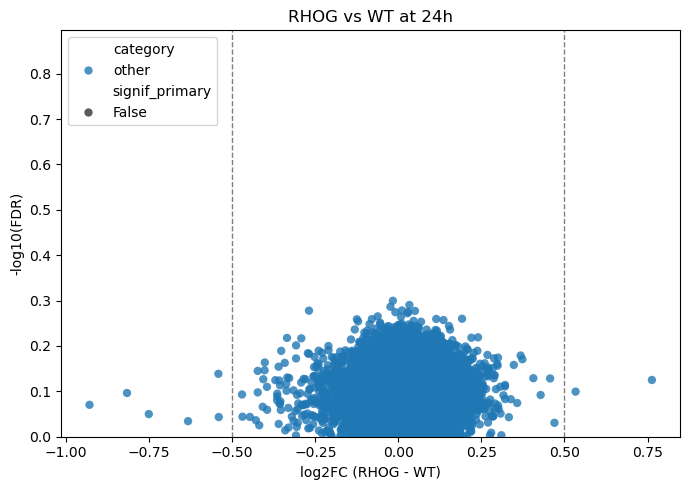

In [15]:
timepoint = 24  # or 0, 72, etc.

de_24 = de_rhog_vs_wt_at_time(expr_logcpm, meta, timepoint=timepoint)
de_24 = annotate_gene_categories(de_24, gene_sets)

plot_volcano_pub(
    de_24,
    title=f"RHOG vs WT at {timepoint}h",
    log2fc_thresh=0.5,
    padj_primary=0.05,
    padj_secondary=0.10,
    highlight_categories=[
        "effector_cytotoxic",
        "exhaustion_checkpoint",
        "regulatory_stress",
        "migration_cytoskeleton",
    ],
)



=== Time 0h ===


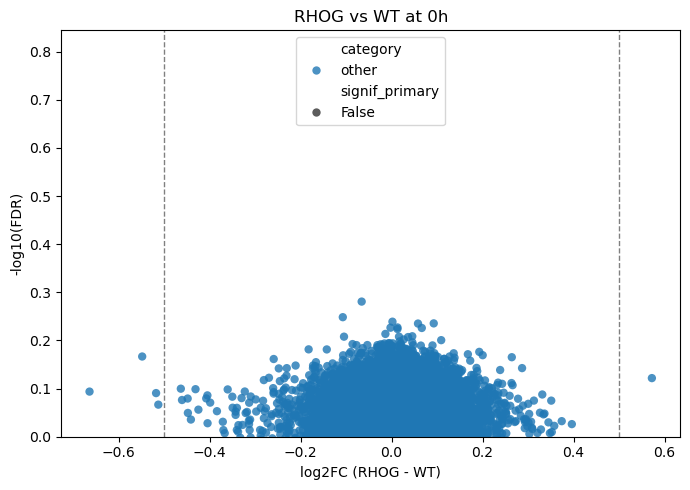


=== Time 24h ===


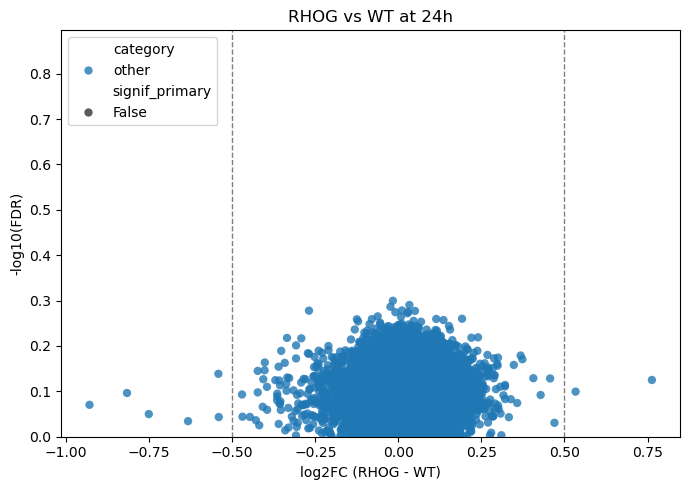


=== Time 72h ===


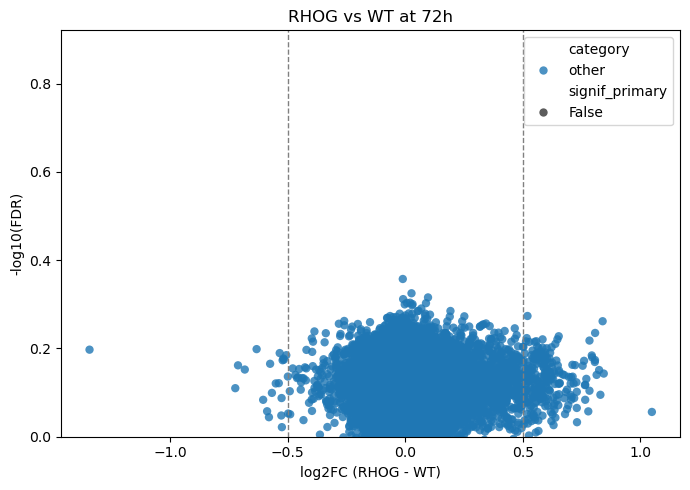


=== Time 168h ===


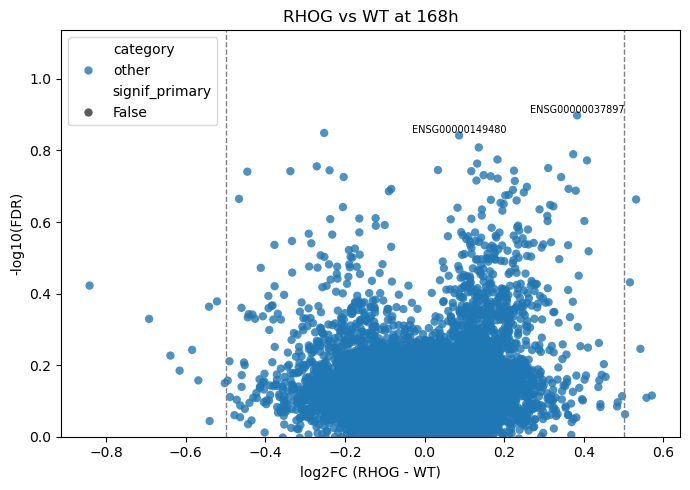


=== Time 240h ===


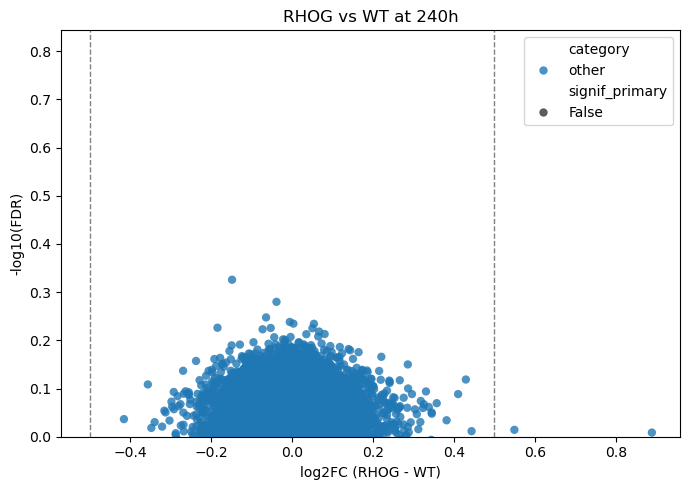

In [16]:
for tp in sorted(meta["hours"].unique()):
    print(f"\n=== Time {tp}h ===")
    de_tp = de_rhog_vs_wt_at_time(expr_logcpm, meta, timepoint=tp)
    de_tp = annotate_gene_categories(de_tp, gene_sets)
    plot_volcano_pub(
        de_tp,
        title=f"RHOG vs WT at {tp}h",
        log2fc_thresh=0.5,
        padj_primary=0.05,
        padj_secondary=0.10,
        highlight_categories=[
            "effector_cytotoxic",
            "exhaustion_checkpoint",
            "regulatory_stress",
            "migration_cytoskeleton",
        ],
    )
